In [22]:
###run this to see if PMM working

import sys
import os
# Add the parent folder (PMM-Design) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

# # Run these 2 lines:
# PMM.Set_Bulb_VI('all', 10, 10) #set bulbs(all, volts, amps)
# PMM.Activate_Bulb('all')

# # OR run these 2 lines:
# PMM.Config_Check()
PMM.Deactivate_Bulb('all')


Best-fit k = 0.3600
RMSE at best k = 0.5775 GHz
RMSE at old k = 0.33: 0.5864 GHz


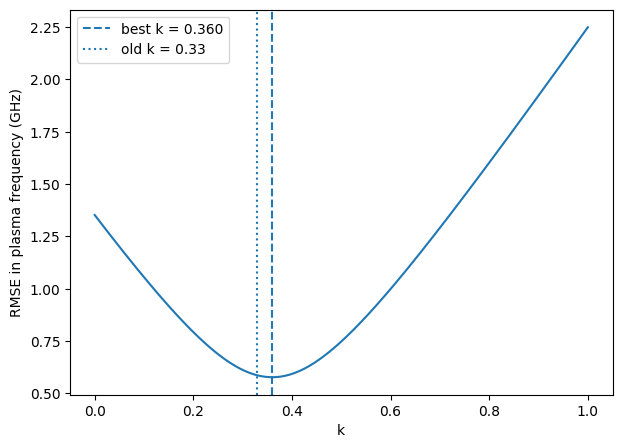

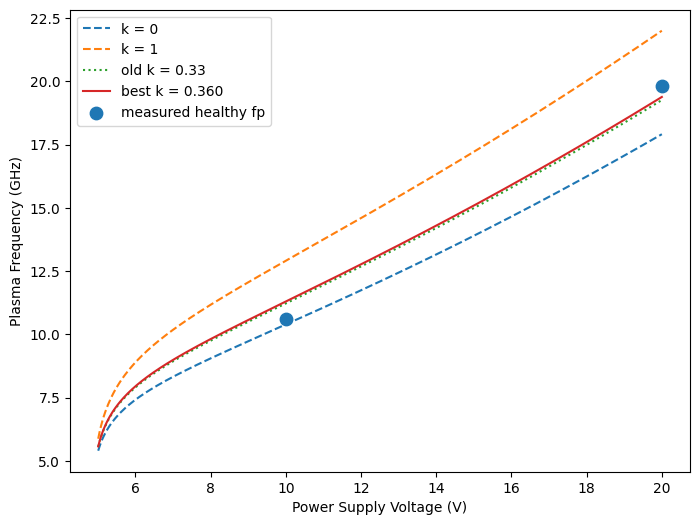

In [ ]:
# Find best k for density fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# BOLSIG fits
def fp_from_I(I, k, S=1.0):
    return S*((2.17164 + 0.30362*k) + (0.28590 + 0.12268*k)*I + (0.45998 - 0.01993*k)*I**2 + (-0.05911 + 0.01684*k)*I**3)

def fp_from_V(V, k, S=1.0):
    return S*((1.7098 + 0.9044*k)*np.log(V - 4.8)/np.log(5) + (0.1346 + 0.02048*k)*(V - 4.8)**1.5 + (7.0415 + 1.3487*k))

# Healthy experimental plasma-frequency measurements
data = pd.DataFrame({
    "mode": ["V", "V"],
    "setting": [10.0, 20.0],
    "fp_measured": [10.60, 19.81]
})

def predict_fp(row, k):
    return fp_from_V(row["setting"], k) if row["mode"] == "V" else fp_from_I(row["setting"], k)

def rmse_for_k(k):
    pred = np.array([predict_fp(row, k) for _, row in data.iterrows()])
    return np.sqrt(np.mean((pred - data["fp_measured"].to_numpy())**2))

result = minimize_scalar(rmse_for_k, bounds=(0.0, 1.0), method="bounded")
best_k = result.x

print(f"Best-fit k = {best_k:.4f}")
print(f"RMSE at best k = {result.fun:.4f} GHz")
print(f"RMSE at old k = 0.33: {rmse_for_k(0.33):.4f} GHz")

# Plot error vs k
k_vals = np.linspace(0, 1, 201)
plt.figure(figsize=(7,5))
plt.plot(k_vals, [rmse_for_k(k) for k in k_vals])
plt.axvline(best_k, linestyle="--", label=f"best k = {best_k:.3f}")
plt.axvline(0.33, linestyle=":", label="old k = 0.33")
plt.xlabel("k")
plt.ylabel("RMSE in plasma frequency (GHz)")
plt.legend()
plt.show()

# Plot measured points against BOLSIG curves
V = np.linspace(5.01, 20, 400)
plt.figure(figsize=(8,6))
plt.plot(V, fp_from_V(V, 0), "--", label="k = 0")
plt.plot(V, fp_from_V(V, 1), "--", label="k = 1")
plt.plot(V, fp_from_V(V, 0.33), ":", label="old k = 0.33")
plt.plot(V, fp_from_V(V, best_k), label=f"best k = {best_k:.3f}")
plt.scatter(data["setting"], data["fp_measured"], s=80, label="measured healthy fp")
plt.xlabel("Power Supply Voltage (V)")
plt.ylabel("Plasma Frequency (GHz)")
plt.legend()
plt.show()

In [ ]:
# Run Bayes opt for demux
import numpy as np
import os
from PMM.PMMInSitu import PMMInSitu

# Settings
progress_dir = "../outputs/demult_bayes_6port"
fpm, k, S = 18.0, 0.36, 1.0
f1, f2, df = 4.0, 6.0, 0.5
n_total_calls, n_initial_points = 500, 20
duty_cycle, warmup_time = 0.75, 10
fwin = [0, 10]

# Start fresh from saved Demult call 248
source_ID = "_S21_S31_only_from_wvg_run1"
demult_start_run = 248
ID = "_S21_S31_true_demux20_from_demult_run248_run1"

# Objective settings
w_trans, w_iso = 1.0, 1.0
target_ports = ["S21", "S31"]
wrong_port_weights = {"S21": 1.0, "S31": 1.0, "S41": 0.25, "S51": 0.25, "S61": 0.25}
plot_ports = ["S21", "S31"]

# Initialize hardware
PMM = PMMInSitu("../confs/conf_test.yaml", conf_dir="../confs/")
num_bulbs = sum(len(x) for x in PMM.config["serial_ports"].values())

# Load starting rho
rho_path = os.path.join(progress_dir, f"rho_Demult_{f1:.1f}_{f2:.1f}GHz_fpm_{fpm:.1f}GHz{source_ID}.csv")
rho_mat = np.atleast_2d(np.loadtxt(rho_path, delimiter=","))
rho0 = rho_mat[demult_start_run - 1].copy()

if rho0.size != num_bulbs:
    raise ValueError(f"rho0 has {rho0.size} values, expected {num_bulbs}")

# Make sure this is a fresh run
for prefix in ["rho", "obj", "norms"]:
    path = os.path.join(progress_dir, f"{prefix}_Demult_{f1:.1f}_{f2:.1f}GHz_fpm_{fpm:.1f}GHz{ID}.csv")
    if os.path.isfile(path):
        raise FileExistsError(f"Run ID already exists: {ID}")

print(f"Starting fresh demux run from call {demult_start_run}")
print(f"New ID: {ID}")
print(f"k = {k}")

try:
    result = PMM.optimize_demult_bayes(
        n_total_calls=n_total_calls, rho=rho0,
        fpm=fpm, k=k, S=S,
        f1=f1, f2=f2, df=df,
        n_initial_points=n_initial_points, objective="dB_6port",
        wu=warmup_time, progress_dir=progress_dir, fwin=fwin,
        duty_cycle=duty_cycle, show=True, show_each_call=False, ID=ID,
        w_trans=w_trans, w_iso=w_iso,
        target_ports=target_ports, wrong_port_weights=wrong_port_weights, plot_ports=plot_ports,
        active_health_every=10,
        active_health_V=10.0, active_health_I=10.0,
        active_health_warmup=5.0, active_health_cooldown=3.0,
        active_health_stop_W=25.0,
        random_state=None
    )

except RuntimeError as exc:
    if "HIGH POWER SAFETY STOP" in str(exc):
        print("\nBayesian optimization stopped because a bulb drew more than 25 W.")
    else:
        raise

Starting fresh demux run from call 248
New ID: _S21_S31_penalty456_from_demult_run248_run2
k = 0.36
No matching demultiplexer logs found. Starting COLD START.
Running array warmup for 10 cycles.
Warmup cycle 1
[WARN] These supplies missed Activate_Bulb('all'): [33, 40, 45, 47]
[WARN] Retrying missed supplies individually...
Warmup cycle 2
[WARN] These supplies missed Activate_Bulb('all'): [47]
[WARN] Retrying missed supplies individually...
Warmup cycle 3
[WARN] These supplies missed Activate_Bulb('all'): [27, 43, 45, 47, 48]
[WARN] Retrying missed supplies individually...
Warmup cycle 4
[WARN] These supplies missed Activate_Bulb('all'): [13, 45]
[WARN] Retrying missed supplies individually...
Warmup cycle 5
[WARN] These supplies missed Activate_Bulb('all'): [73, 80]
[WARN] Retrying missed supplies individually...
Warmup cycle 6
[WARN] These supplies missed Activate_Bulb('all'): [18, 47, 65]
[WARN] Retrying missed supplies individually...
Warmup cycle 7
[WARN] These supplies missed Act